# Notebook 04 - Precision Experiment

The final network from notebook 03 is trained once on each of the four precision levels and scored on the test split. Every level uses the same seed, so all four start from the same weights and see the same batches, and the only difference between them is the precision. The result is put next to the storage each level saves.

### Step 1 - Import Libraries

In [1]:
import os
import tensorflow as tf                           
import keras                                      
print("Tensorflow/Keras: %s / %s" % (tf.__version__, keras.__version__))   
from keras.models import Sequential, Model        
from keras import Input                           
from keras.layers import Dense, Dropout, Embedding, Concatenate   
from keras.optimizers import Adam                 
from keras.callbacks import EarlyStopping         
import pandas as pd                               
print("pandas: %s" % pd.__version__)              
import numpy as np                                
print("numpy: %s" % np.__version__)               
import matplotlib.pyplot as plt                   
import json                                       
import time                                       

Tensorflow/Keras: 2.21.0 / 3.15.1
pandas: 2.3.3
numpy: 2.5.3


In [1]:
def jupyter_settings():
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({
        "figure.figsize": (12, 6),
        "figure.dpi": 100,
        "axes.titlesize": 14,
        "axes.labelsize": 12,
        "legend.fontsize": 10,
        "savefig.bbox": "tight",
        "savefig.dpi": 120,
    })
    pd.set_option("display.max_columns", 30)
    pd.set_option("display.float_format", "{:,.2f}".format)

jupyter_settings()

NameError: name 'plt' is not defined

### Step 2 - Settings

The design comes from the file written by notebook 03, so nothing is typed again.

In [2]:
NN_DIR = os.path.expanduser("~/ca1/data/nn")
RESULTS = os.path.expanduser("~/ca1/results")
FIGURES = os.path.expanduser("~/ca1/figures")
RESULTS_FILE = f"{RESULTS}/04_results.csv"                

with open(f"{RESULTS}/03_final_config.json") as f:
    frozen = json.load(f)
PHASE, SCALER, SEED, MARGIN_PCT = frozen["phase"], frozen["scaler"], frozen["seed"], frozen["margin_pct"]
Y_SCALE, BATCH, EPOCHS, PATIENCE = frozen["y_scale"], frozen["batch"], frozen["epochs"], frozen["patience"]
print(frozen)

LEVELS = ["L0", "D1", "D0", "T15"]
tf.config.experimental.enable_op_determinism()            

{'phase': 'P2', 'scaler': 'standard', 'seed': 1234, 'margin_pct': 1.0, 'y_scale': 600.0, 'batch': 1024, 'epochs': 100, 'patience': 5}


### Step 3 - Functions

The same functions as notebook 03, copied so this notebook runs on its own.

In [3]:
def load_level(name):
    # one extract / split into train, validation and test
    data = pd.read_parquet(f"{NN_DIR}/{name}").sort_values("trip_id")       # same row order at every level
    return {s: data[data["split"] == s] for s in ["train", "validation", "test"]}

def make_inputs(data, phase, scaler):
    numbers = data[[f"dist_{scaler}", "hour_sin", "hour_cos"]].to_numpy("float32")   # distance in the chosen scaling, and the hour
    days = keras.utils.to_categorical(data["dow"], num_classes=7)                    # one-hot day of week, 7 switches with one on
    if phase == "P1":
        zones = data[["PULocationID", "DOLocationID"]].to_numpy("float32") / 265     # zone id as a plain number between 0 and 1
        return np.hstack([numbers, days, zones])                                     # one input with 12 numbers
    return [np.hstack([numbers, days]),                                              # 10 numbers
            data["PULocationID"].to_numpy("int32"),                                  # pickup zone id, goes to the embedding
            data["DOLocationID"].to_numpy("int32")]                                  # dropoff zone id, goes to the embedding


def build_model(phase):
    if phase == "P1":
        # Phase 1 is a plain stack of layers with one input
        model = Sequential(name="MLP-P1")
        model.add(Input(shape=(12,), name="Input-Layer"))                                                    # 3 numbers + 7 days + 2 zone ids
        model.add(Dense(64, activation="relu", name="Hidden-Layer-1"))                                       # first hidden layer, 64 neurons
        model.add(Dense(32, activation="relu", name="Hidden-Layer-2"))                                       # second hidden layer, 32 neurons
        model.add(Dense(1, activation="linear", name="Output-Layer"))                                        # one number, the predicted duration
    else:
        # Phases 2 and 3 are functional API, because the zones enter through their own inputs
        numbers = Input(shape=(10,), name="Input-Numbers")                                                   # 3 numbers + 7 days
        pickup = Input(shape=(), dtype="int32", name="Input-Pickup-Zone")
        dropoff = Input(shape=(), dtype="int32", name="Input-Dropoff-Zone")
        zone_table = Embedding(input_dim=266, output_dim=8, name="Zone-Embedding")                           # ids go up to 265, each zone gets 8 learned numbers
        x = Concatenate(name="Concatenate-Layer")([numbers, zone_table(pickup), zone_table(dropoff)])        # one table shared by pickup and dropoff
        x = Dense(64, activation="relu", name="Hidden-Layer-1")(x)
        if phase == "P3":
            x = Dropout(0.2, name="Dropout-1")(x)                                                             # switches off 20% of the neurons at random while training
        x = Dense(32, activation="relu", name="Hidden-Layer-2")(x)
        if phase == "P3":
            x = Dropout(0.2, name="Dropout-2")(x)
        output = Dense(1, activation="linear", name="Output-Layer")(x)
        model = Model(inputs=[numbers, pickup, dropoff], outputs=output, name=f"MLP-{phase}")

    model.compile(optimizer=Adam(learning_rate=1e-3),        
                  loss="mean_squared_error",                 
                  metrics=["mean_absolute_error"],           
                  steps_per_execution=32)                    
    return model


def train_and_score(data, phase, scaler, seed, split="validation"):
    keras.utils.set_random_seed(seed)                                                                            # same seed, same starting weights and same batches
    model = build_model(phase)
    y_train = data["train"]["duration_s_true"].to_numpy("float32") / Y_SCALE                                     # target in blocks of 10 minutes
    y_val = data["validation"]["duration_s_true"].to_numpy("float32") / Y_SCALE
    start = time.time()
    history = model.fit(make_inputs(data["train"], phase, scaler), y_train,
                        validation_data=(make_inputs(data["validation"], phase, scaler), y_val),
                        batch_size=BATCH, epochs=EPOCHS, verbose=0,
                        callbacks=[EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)])
    pred = model.predict(make_inputs(data[split], phase, scaler), batch_size=8192, verbose=0).ravel() * Y_SCALE   # back to seconds
    result = {"MAE (s)": np.abs(pred - data[split]["duration_s_true"].to_numpy()).mean(),                         # error in second
              "Best epoch": int(np.argmin(history.history["val_loss"])) + 1,                                      # the epoch early stopping kept
              "Minutes": (time.time() - start) / 60}
    print(f"{phase} {scaler} seed {seed} | MAE {result['MAE (s)']:.1f} s | best epoch {result['Best epoch']} | {result['Minutes']:.1f} min")
    return result, history.history

### Step 4 - Training Every Level

One training per level which gives us four in total. At every level the distance is scaled with the statistics of that level's own training split, computed in notebook 03. Each result is saved as soon as the training ends to avoid dataloss. 

In [4]:
runs = pd.read_csv(RESULTS_FILE).to_dict("records") if os.path.exists(RESULTS_FILE) else []   # trainings already done, if the VM stopped before
done = [r["Level"] for r in runs]

for level in LEVELS:
    if level in done:
        continue                                           
    result, _ = train_and_score(load_level(level), PHASE, SCALER, SEED, split="test")   # the test split is used only here
    runs.append({"Level": level, **result})                                             # adds MAE, best epoch and minutes
    pd.DataFrame(runs).to_csv(RESULTS_FILE, index=False)

P2 standard seed 1234 | MAE 183.5 s | best epoch 43 | 7.2 min


P2 standard seed 1234 | MAE 183.1 s | best epoch 54 | 9.0 min


P2 standard seed 1234 | MAE 195.8 s | best epoch 39 | 6.7 min


P2 standard seed 1234 | MAE 184.7 s | best epoch 28 | 5.1 min


The four lines above are, in this order, L0, D1, D0 and T15. L0 keeps epoch 43, the same as P2 in notebook 03, because the training data and the seed are the same. Only the split for the score changes. The L0 test MAE, 183.5 s, is 3.4% above the P2 validation MAE, 177.5 s.

### Step 5 - Comparison with L0

Each level is compared with L0. As in notebook 03, a change smaller than 1% of the L0 error is treated as no difference, because one training per level cannot separate it from the variation of the training itself.

In [5]:
comparison = pd.DataFrame(runs).set_index("Level").loc[LEVELS]      # one row per level
comparison["Diff vs L0 (s)"] = comparison["MAE (s)"] - comparison.loc["L0", "MAE (s)"]
comparison["Diff (%)"] = comparison["Diff vs L0 (s)"] / comparison.loc["L0", "MAE (s)"] * 100
comparison["Beyond the margin"] = comparison["Diff (%)"].abs() > MARGIN_PCT
comparison

,MAE (s),Best epoch,Minutes,Diff vs L0 (s),Diff (%),Beyond the margin
Level,,,,,,
L0,183.51,43,7.20,0.00,0.00,False
D1,183.11,54,8.95,-0.40,-0.22,False
D0,195.78,39,6.67,12.27,6.68,True
T15,184.67,28,5.10,1.16,0.63,False


L0 has a test MAE of 183.5 s, and the 1% margin is 1.84 s. D0 is the only level outside the margin, with 12.27 s more, or 6.7%. With whole miles, the distance has only 67 values, thus trips of 0.6 and 1.4 miles go into the network with the same value. D1 and T15 are inside the margin, with −0.40 s and +1.16 s. With one training per level, this means that no effect is larger than 1%, not that there is no effect.

### Step 6 - Precision Budget

The storage kept at each level against the change in test error. The grey band is the 1% margin.

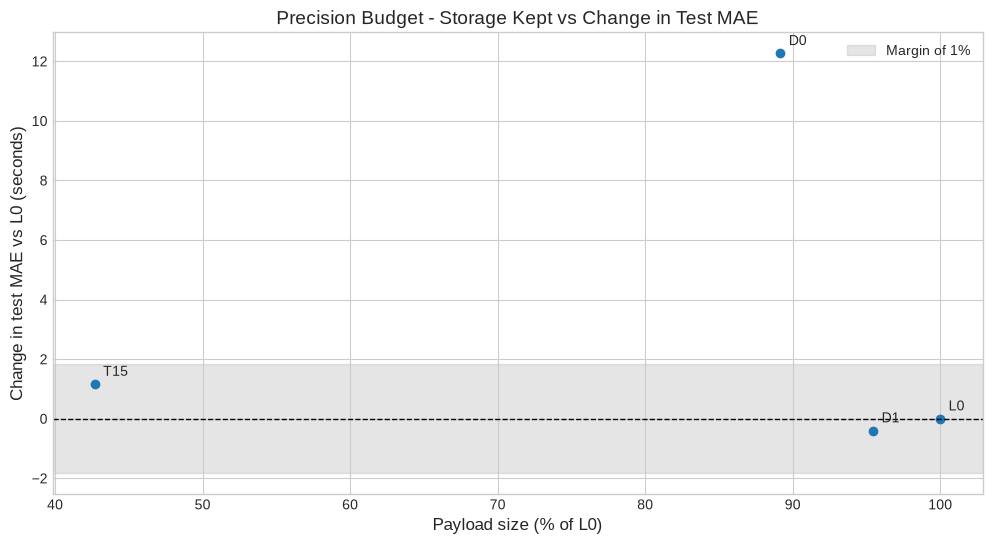

,Storage (% of L0),Diff vs L0 (s)
L0,100.00,0.00
D1,95.46,-0.40
D0,89.17,12.27
T15,42.69,1.16


In [6]:
storage = pd.read_csv(f"{RESULTS}/02_levels.csv", index_col="level")
budget = pd.DataFrame({"Storage (% of L0)": storage.loc[LEVELS, "size_vs_L0_pct"],
                       "Diff vs L0 (s)": comparison["Diff vs L0 (s)"]})
margin = comparison.loc["L0", "MAE (s)"] * MARGIN_PCT / 100

plt.figure(figsize=(12, 6))
plt.axhspan(-margin, margin, color="grey", alpha=0.2, zorder=0, label="Margin of 1%")
plt.axhline(0, color="black", linestyle="--", linewidth=1)
plt.scatter(budget["Storage (% of L0)"], budget["Diff vs L0 (s)"])
for level, row in budget.iterrows():
    plt.annotate(level, (row["Storage (% of L0)"], row["Diff vs L0 (s)"]), textcoords="offset points", xytext=(6, 6))
plt.title("Precision Budget - Storage Kept vs Change in Test MAE")
plt.xlabel("Payload size (% of L0)")
plt.ylabel("Change in test MAE vs L0 (seconds)")
plt.legend()
plt.savefig(f"{FIGURES}/04_precision_budget.png")
plt.show()
budget

T15 is the best point on the chart. It keeps only 42.7% of the L0 payload, and the test MAE changes by only 0.63%, inside the margin. D1 saves 4.5% and is also inside the margin. D0 saves 10.8%, but it is outside the margin. Thus, the truncation of the timestamps gives the best trade-off, and the distance cannot lose all its decimals.

### Step 7 - Saving the Results

In [7]:
comparison.to_csv(f"{RESULTS}/04_comparison.csv")
budget.to_csv(f"{RESULTS}/04_budget.csv")